<a href="https://colab.research.google.com/github/NosiphoHlongwane/HIV-AIDS-prevalence-comparative-analysis/blob/main/HIV_Prevalance_comparative_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

In [ ]:
# uploading dataset
from google.colab import files
uploaded = files.upload()

Saving HIV_AIDS prevalence estimates table.csv to HIV_AIDS prevalence estimates table.csv


In [ ]:
#reading the dataset

df = pd.read_csv('HIV_AIDS prevalence estimates table.csv', encoding='Latin1')
df.head()

,Country/Region,Adult prevalence of HIV/AIDS,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
0,ÿEswatini,28.30%,"240,000","3,000",2024
1,ÿLesotho,26.20%,"445,000","7,000",2025
2,ÿBotswana,22.80%,"399,100","5,275",2025
3,ÿZimbabwe,22.10%,"1,660,000","25,600",2024
4,ÿSouth Africa,14.40%,"9,400,000","80,000",2025


In [ ]:
# checking if df works
assert 'df' in globals(), 'Dataframe df not found. Please run earlier cells to load data'

In [ ]:
# stats summary

display(df.describe(include='all'))

,Country/Region,Adult prevalence of HIV/AIDS,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
count,193,193,192,193,193
unique,193,73,168,56,16
top,ÿEswatini,-,"11,000",-,2024
freq,1,53,6,126,57


In [ ]:
# checking missing values

print('\nMissing values per column:')
print(df.isna().sum().sort_values(ascending=False))


Missing values per column:
Number of people with HIV/AIDS    1
Country/Region                    0
Adult prevalence of HIV/AIDS      0
Annual deaths from HIV/AIDS       0
Year of estimate                  0
dtype: int64


In [ ]:
# basic count

n_rows, n_cols = df.shape
print(f"\nRows {n_rows}, Columns: {n_cols}")
if 'Country\Region' in df.columns:
  print('Unique Country/Region:', df['Country\Region'].nunique())


Rows 193, Columns: 5


In [ ]:
df.head()

,Country/Region,Adult prevalence of HIV/AIDS,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
0,ÿEswatini,28.30%,"240,000","3,000",2024
1,ÿLesotho,26.20%,"445,000","7,000",2025
2,ÿBotswana,22.80%,"399,100","5,275",2025
3,ÿZimbabwe,22.10%,"1,660,000","25,600",2024
4,ÿSouth Africa,14.40%,"9,400,000","80,000",2025


In [ ]:
df.tail()

,Country/Region,Adult prevalence of HIV/AIDS,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
188,ÿAndorra,-,600,-,2025
189,ÿFederated States of Micronesia,-,149,-,2025
190,ÿJordan,-,"2,000",-,2025
191,ÿLuxembourg,-,"5,700",-,2025
192,ÿMaldives,-,660,-,2025


In [ ]:
# data cleaning 1

df['Country/Region'] = df['Country/Region'].astype(str).apply(lambda x: re.sub(r'^[^A-Za-z0-9]+','',x).strip())
df['Adult prevalence of HIV/AIDS'] = df['Adult prevalence of HIV/AIDS'].\
                                    astype(str).str.replace('%','').str.replace(',','').str.strip()
df['Adult prevalence of HIV/AIDS'] =pd.to_numeric(df['Adult prevalence of HIV/AIDS'], errors='coerce')

def to_int_col(s):
  return pd.to_numeric(s.astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce').astype('Int64')

In [ ]:
# data cleaning 2

df['Number of people with HIV/AIDS'] = to_int_col(df['Number of people with HIV/AIDS'])
df['Annual deaths from HIV/AIDS'] = to_int_col(df['Annual deaths from HIV/AIDS'])
df['Year of estimate'] =pd.to_numeric(df['Year of estimate'], errors='coerce').astype('Int64')
df['Death_per_1000_infected'] = df['Annual deaths from HIV/AIDS'] / df['Number of people with HIV/AIDS'] * 1000
df['Death_per_1000_infected'] = df['Death_per_1000_infected'].round(2)


In [ ]:
out_csv = "/content/HIV_AIDS_prevalence_cleaned.csv"
df.to_csv(out_csv, index=False)

In [ ]:
# table for analysis

top10_prevalence = df.sort_values('Adult prevalence of HIV/AIDS', ascending=False).head(10)
top10_cases = df.sort_values('Number of people with HIV/AIDS', ascending=False).head(10)
top10_deaths = df.sort_values('Annual deaths from HIV/AIDS', ascending=False).head(10)

high_prev_low_deaths = (
    df[(df['Adult prevalence of HIV/AIDS'] > 5) & df['Death_per_1000_infected'].notna()]
    .sort_values('Death_per_1000_infected')
    .head(10)
)

In [ ]:
# correlation

corr_prevalence_deaths = df[['Adult prevalence of HIV/AIDS', 'Annual deaths from HIV/AIDS']].dropna().corr().iloc[0,1]

corr_cases_deaths = df[['Number of people with HIV/AIDS', 'Annual deaths from HIV/AIDS']].dropna().corr().iloc[0,1]

In [ ]:
plots_dir = Path("/mnt/data/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# prevalence vs deaths plot 1

plt.figure(figsize=(8,6))
valid = df[['Adult prevalence of HIV/AIDS', 'Annual deaths from HIV/AIDS']].dropna()
plt.scatter(valid['Adult prevalence of HIV/AIDS'], valid['Annual deaths from HIV/AIDS'])
plt.xlabel('Adult prevalence of HIV/AIDS')
plt.ylabel('Annual deaths from HIV/AIDS')
plt.title('Prevalence (%) vs Annual Deaths from HIV/AIDS')
plt.grid(True)
plt.tight_layout()
p1 = plots_dir / "prevalenve_vs_deaths.png"
plt.savefig(p1)
plt.close()

In [ ]:
# cases vs deaths (log x)

plt.figure(figsize=(8,6))
valid2 = df[['Number of people with HIV/AIDS', 'Annual deaths from HIV/AIDS']].dropna()
plt.scatter(valid2['Number of people with HIV/AIDS'], valid2['Annual deaths from HIV/AIDS'])
plt.xscale('log')
plt.xlabel('Number of people with HIV/AIDS (logscale)')
plt.ylabel('Annual deaths from HIV/AIDS')
plt.title('Cases vs Annual Deaths from HIV/AIDS (log x-axis)')
plt.grid(True)
plt.tight_layout()
p2 = plots_dir / "cases_vs_deaths_logx.png"
plt.savefig(p2)
plt.close()

In [ ]:
# Exploratory Data Analysis

print("Cleaned dataset (first 50 rows)")
display(df.head(50))

print("Top 10 countries by adult prevalence(%)")
display(top10_prevalence[['Country/Region',
                           'Number of people with HIV/AIDS',
                           'Annual deaths from HIV/AIDS',
                           'Year of estimate']])

print("Top 10 countries by number of cases")
display(top10_cases[['Country/Region',
                     'Number of people with HIV/AIDS',
                     'Annual deaths from HIV/AIDS',
                     'Year of estimate']])

print("Top 10 countries by annual deaths")
display(top10_deaths[['Country/Region',
                      'Number of people with HIV/AIDS',
                      'Annual deaths from HIV/AIDS',
                      'Year of estimate']])

print("High prevalence but low deaths 1000 infected")
display(high_prev_low_deaths[['Country/Region',
                              'Number of people with HIV/AIDS',
                              'Annual deaths from HIV/AIDS',
                              'Year of estimate',
                              'Death_per_1000_infected']])

Cleaned dataset (first 50 rows)


,Country/Region,Adult prevalence of HIV/AIDS,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate,Death_per_1000_infected
0,Eswatini,28.30,240000,3000,2024,12.5
1,Lesotho,26.20,445000,7000,2025,15.73
2,Botswana,22.80,399100,5275,2025,13.22
3,Zimbabwe,22.10,1660000,25600,2024,15.42
4,South Africa,14.40,9400000,80000,2025,8.51
5,Mozambique,12.65,2485000,59100,2024,23.78
6,Malawi,11.40,1642570,15270,2024,9.3
7,Equatorial Guinea,7.66,74165,2400,2024,32.36
8,Tanzania,7.00,3300000,39000,2025,11.82
9,Kenya,5.10,1710000,24000,2023,14.04


Top 10 countries by adult prevalence(%)


,Country/Region,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
0,Eswatini,240000,3000,2024
1,Lesotho,445000,7000,2025
2,Botswana,399100,5275,2025
3,Zimbabwe,1660000,25600,2024
4,South Africa,9400000,80000,2025
5,Mozambique,2485000,59100,2024
6,Malawi,1642570,15270,2024
7,Equatorial Guinea,74165,2400,2024
8,Tanzania,3300000,39000,2025
11,Togo,220440,6600,2024


Top 10 countries by number of cases


,Country/Region,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
30,Russian Federation[10],140000011,24000,2023
102,United Kingdom,11600017,<NA>,2024
4,South Africa,9400000,80000,2025
177,Uzbekistan,4865836,<NA>,2024
8,Tanzania,3300000,39000,2025
5,Mozambique,2485000,59100,2024
23,Nigeria,2450000,56500,2024
88,India,2300000,35000,<NA>
101,Switzerland,1800016,<NA>,2022
9,Kenya,1710000,24000,2023


Top 10 countries by annual deaths


,Country/Region,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate
4,South Africa,9400000,80000,2025
5,Mozambique,2485000,59100,2024
23,Nigeria,2450000,56500,2024
68,Indonesia,660000,47000,2024
8,Tanzania,3300000,39000,2025
88,India,2300000,35000,<NA>
3,Zimbabwe,1660000,25600,2024
42,Ethiopia,760000,25000,2024
41,Thailand,800000,25000,2024
30,Russian Federation[10],140000011,24000,2023


High prevalence but low deaths 1000 infected


,Country/Region,Number of people with HIV/AIDS,Annual deaths from HIV/AIDS,Year of estimate,Death_per_1000_infected
4,South Africa,9400000,80000,2025,8.51
6,Malawi,1642570,15270,2024,9.3
8,Tanzania,3300000,39000,2025,11.82
0,Eswatini,240000,3000,2024,12.5
2,Botswana,399100,5275,2025,13.22
9,Kenya,1710000,24000,2023,14.04
3,Zimbabwe,1660000,25600,2024,15.42
1,Lesotho,445000,7000,2025,15.73
5,Mozambique,2485000,59100,2024,23.78
11,Togo,220440,6600,2024,29.94


In [ ]:
summary = {
    "num of countries": int(df.shape[0]),
    "countries_with_prevalence_data": int(df['Adult prevalence of HIV/AIDS'].notna().sum()),
    "countries_with_cases_data": int(df['Number of people with HIV/AIDS'].notna().sum()),
    "countries_with_deaths_data": int(df['Annual deaths from HIV/AIDS'].notna().sum()),
    "correlation_prevalence_deaths": round(float(corr_prevalence_deaths), 3) if not pd.isna(corr_prevalence_deaths) else None,
    "correlation_cases_deaths": round(float(corr_cases_deaths), 3) if not pd.isna(corr_cases_deaths) else None,
    "Cleaned_csv": out_csv,
    "plots": {
        "prevalence_vs_deaths": str(p1),
        "cases_vs_deaths_logx": str(p2)
    }
}



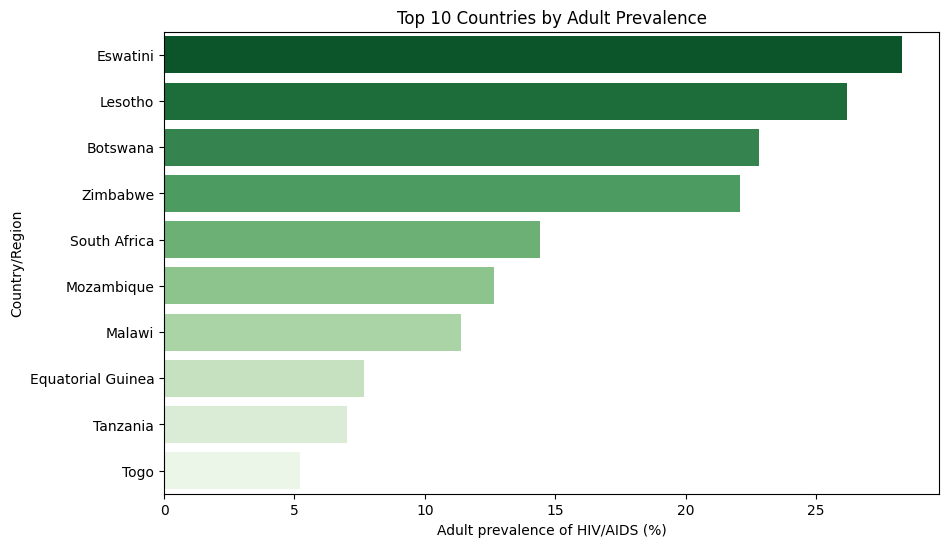

In [ ]:
# Visualisation

import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_prevalence,
    x='Adult prevalence of HIV/AIDS',
    y='Country/Region',
    hue='Country/Region',
    palette='Greens_r',
    dodge=False
    )
plt.xlabel('Adult prevalence of HIV/AIDS (%)')
plt.ylabel('Country/Region')
plt.title('Top 10 Countries by Adult Prevalence')
plt.tight_layout
p3 = plots_dir / "top10_prevalence.png"
plt.savefig(p3)
plt.show()



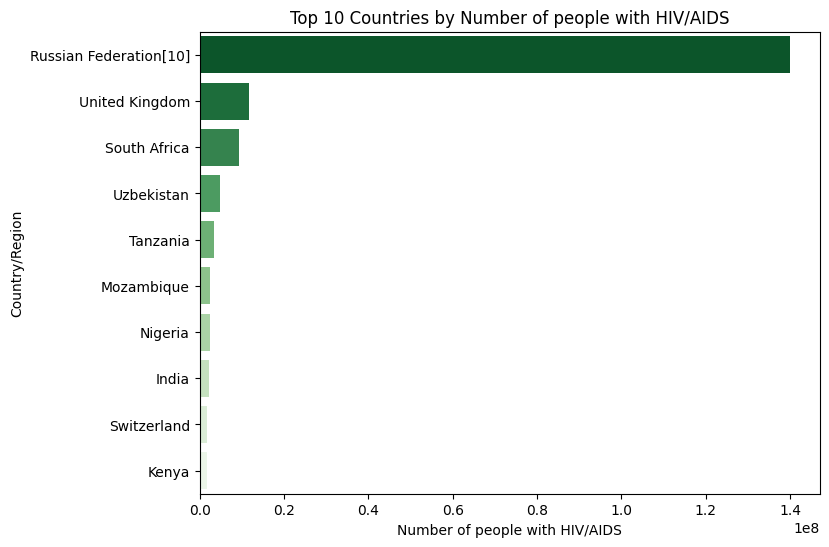

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=top10_cases,
    x='Number of people with HIV/AIDS',
    y='Country/Region',
    hue='Country/Region',
    palette='Greens_r',
    dodge=False
    )
plt.xlabel('Number of people with HIV/AIDS')
plt.ylabel('Country/Region')
plt.title('Top 10 Countries by Number of people with HIV/AIDS')
plt.tight_layout
p4=plots_dir / "top10_cases.png"
plt.savefig(p4)
plt.show()

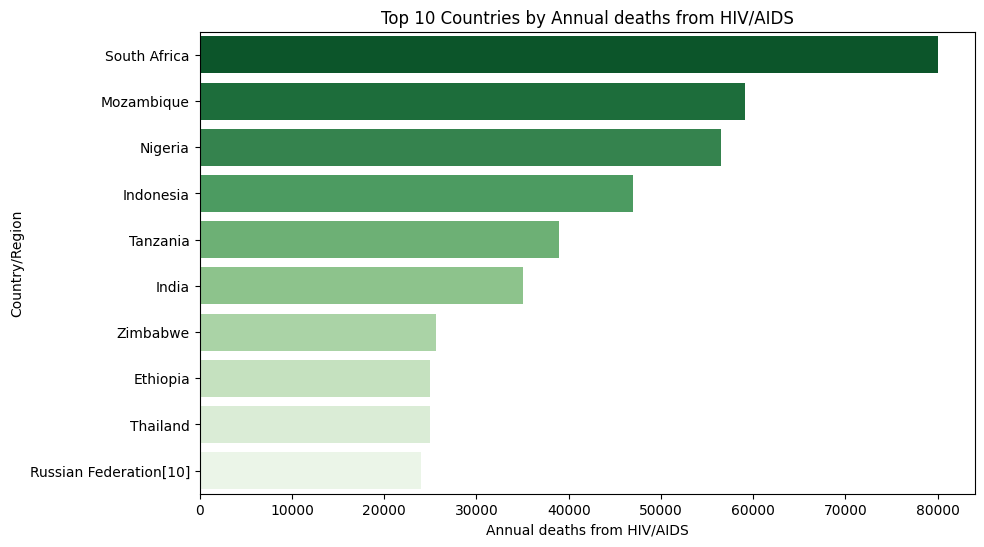

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_deaths,
    x='Annual deaths from HIV/AIDS',
    y='Country/Region',
    hue='Country/Region',
    palette='Greens_r',
    dodge=False
    )
plt.xlabel('Annual deaths from HIV/AIDS')
plt.ylabel('Country/Region')
plt.title('Top 10 Countries by Annual deaths from HIV/AIDS')
plt.tight_layout
p5=plots_dir / "top10_deaths.png"
plt.savefig(p5)
plt.show()

In [ ]:
valid3 = df[['Number of people with HIV/AIDS', 'Death_per_1000_infected']].dropna()

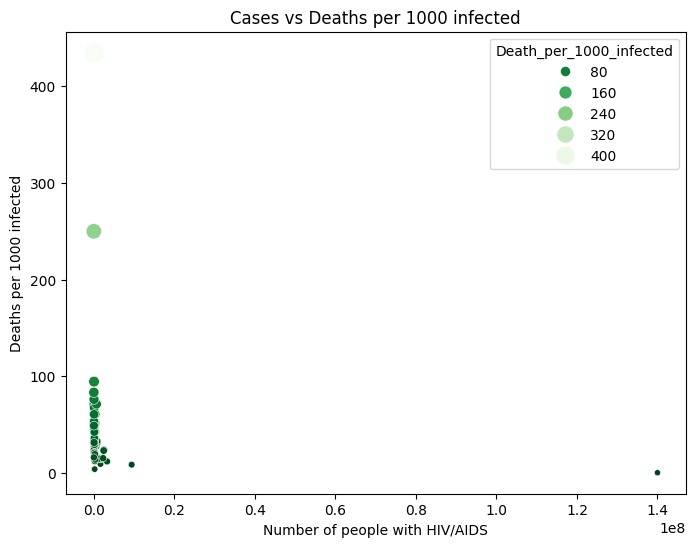

In [ ]:
plt.figure(figsize=(8,6))
valid3['Death_per_1000_infected'] = valid3['Death_per_1000_infected'].astype(float)
sns.scatterplot(
    data=valid3,
    x='Number of people with HIV/AIDS',
    y='Death_per_1000_infected',
    hue='Death_per_1000_infected',
    palette='Greens_r',
    size='Death_per_1000_infected',
    sizes=(20,200)
    )
plt.xlabel('Number of people with HIV/AIDS')
plt.ylabel('Deaths per 1000 infected')
plt.title('Cases vs Deaths per 1000 infected')
plt.show()

In [ ]:
print(valid3.dtypes)

Number of people with HIV/AIDS      Int64
Death_per_1000_infected           Float64
dtype: object
